# Phase 2 - Model 2: Transfer Learning BiLSTM

**Architecture**: Bidirectional LSTM with Temporal Attention  
**Transfer Learning**: Pre-train on UQ data → Fine-tune on CIC data (freeze BiLSTM, train attention + FC)  
**Input**: Z (batch, 30, 64) — shared latent space from Feature Aligner  
**Output**: 5-class probabilities (Benign, BruteForce, DDoS, DoS, Infiltration)

In [1]:
import sys, os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))
from feature_alignment import (
    prepare_combined_dataset, FeatureAligner, create_dataloaders,
    DEVICE, LATENT_DIM, WINDOW_SIZE, NUM_CLASSES, UNIFIED_CLASSES
)

print(f"Device: {DEVICE}")


Device: cuda


## 1. Load & Prepare Data

In [2]:
# Load combined dataset
data = prepare_combined_dataset()

uq_windows = data['uq']['windows']
uq_labels = data['uq']['labels']
cic_windows = data['cic']['windows']
cic_labels = data['cic']['labels']
uq_n_feat = data['uq']['n_features']
cic_n_feat = data['cic']['n_features']

# Split data
def split_data(windows, labels, test_size=0.15, val_size=0.15, seed=42):
    X_trainval, X_test, y_trainval, y_test = train_test_split(
        windows, labels, test_size=test_size, random_state=seed, stratify=labels)
    val_ratio = val_size / (1 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_trainval, y_trainval, test_size=val_ratio, random_state=seed, stratify=y_trainval)
    return X_train, X_val, X_test, y_train, y_val, y_test

uq_train, uq_val, uq_test, uq_y_train, uq_y_val, uq_y_test = split_data(uq_windows, uq_labels)
cic_train, cic_val, cic_test, cic_y_train, cic_y_val, cic_y_test = split_data(cic_windows, cic_labels)

print(f"UQ  — Train: {len(uq_train)}, Val: {len(uq_val)}, Test: {len(uq_test)}")
print(f"CIC — Train: {len(cic_train)}, Val: {len(cic_val)}, Test: {len(cic_test)}")


[UQ] Loaded 1388150 flows, 47 features
[UQ] Label distribution:
Label
Benign          399999
DoS             300000
DDoS            300000
BruteForce      199999
Infiltration    188152
[UQ] Created 186005 windows of shape (186005, 30, 47)
[UQ] Feature dim: 47, Latent target: 64
[CIC] Loaded 237618 flows, 78 features
[CIC] Label distribution:
Label
Benign          100000
DoS              71588
DDoS             50000
BruteForce       15994
Infiltration        36
[CIC] Created 101615 windows of shape (101615, 30, 78)
[CIC] Feature dim: 78, Latent target: 64

=== Combined Dataset ===
UQ: 186005 windows, 47 features
CIC: 101615 windows, 78 features
Total: 287620 windows
UQ  — Train: 130203, Val: 27901, Test: 27901
CIC — Train: 71129, Val: 15243, Test: 15243


## 2. Define TL-BiLSTM Model

**Architecture:**
- BiLSTM: 64→128 (2 bidirectional layers, 64 hidden per direction)
- Temporal Attention: learned weighted sum over time steps
- FC: 128→5

**Transfer Learning Strategy:**
1. Phase 1 — Pre-train on UQ data (all layers trainable)
2. Phase 2 — Fine-tune on combined data (freeze BiLSTM, train attention + classifier)

In [3]:
class TemporalAttention(nn.Module):
    """Attention mechanism over time steps."""

    def __init__(self, hidden_dim):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.Tanh(),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, lstm_output):
        # lstm_output: (batch, time_steps, hidden_dim)
        attn_weights = self.attention(lstm_output)   # (B, T, 1)
        attn_weights = torch.softmax(attn_weights, dim=1)
        context = (lstm_output * attn_weights).sum(dim=1)  # (B, hidden_dim)
        return context, attn_weights.squeeze(-1)


class TL_BiLSTM(nn.Module):
    """
    Transfer Learning Bidirectional LSTM with Temporal Attention.
    """

    def __init__(self, latent_dim=LATENT_DIM, hidden_dim=128, num_layers=2,
                 num_classes=NUM_CLASSES):
        super().__init__()
        self.hidden_dim = hidden_dim

        # BiLSTM (bidirectional → output is 2*hidden_dim per direction = hidden_dim total)
        self.bilstm = nn.LSTM(
            input_size=latent_dim,
            hidden_size=hidden_dim // 2,  # 64 per direction → 128 total
            num_layers=num_layers,
            batch_first=True,
            dropout=0.3,
            bidirectional=True,
        )

        self.attention = TemporalAttention(hidden_dim)
        self.layer_norm = nn.LayerNorm(hidden_dim)

        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, z):
        """
        Args:
            z: (batch, time_steps, latent_dim) — from FeatureAligner
        Returns:
            logits: (batch, num_classes)
        """
        lstm_out, _ = self.bilstm(z)            # (B, 30, 128)
        context, attn_w = self.attention(lstm_out)  # (B, 128)
        context = self.layer_norm(context)
        logits = self.classifier(context)        # (B, 5)
        return logits

    def freeze_bilstm(self):
        """Freeze BiLSTM layers for transfer learning fine-tuning."""
        for param in self.bilstm.parameters():
            param.requires_grad = False
        print("BiLSTM layers frozen.")

    def unfreeze_all(self):
        """Unfreeze all layers."""
        for param in self.parameters():
            param.requires_grad = True
        print("All layers unfrozen.")


class TLBiLSTMWithAligner(nn.Module):
    """End-to-end model: FeatureAligner + TL-BiLSTM."""

    def __init__(self, uq_input_dim, cic_input_dim):
        super().__init__()
        self.aligner = FeatureAligner(uq_input_dim, cic_input_dim)
        self.bilstm = TL_BiLSTM()

    def forward(self, x, dataset_type='uq'):
        z = self.aligner(x, dataset_type)
        logits = self.bilstm(z)
        return logits

    def predict_proba(self, x, dataset_type='uq'):
        logits = self.forward(x, dataset_type)
        return torch.softmax(logits, dim=1)

    def freeze_bilstm(self):
        self.bilstm.freeze_bilstm()

    def unfreeze_all(self):
        self.bilstm.unfreeze_all()


model = TLBiLSTMWithAligner(uq_n_feat, cic_n_feat).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f"TL-BiLSTM Model: {total_params:,} params")
print(model)


TL-BiLSTM Model: 208,646 params
TLBiLSTMWithAligner(
  (aligner): FeatureAligner(
    (uq_extractor): UQFeatureExtractor(
      (net): Sequential(
        (0): Linear(in_features=47, out_features=128, bias=True)
        (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Dropout(p=0.3, inplace=False)
        (4): Linear(in_features=128, out_features=64, bias=True)
        (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (6): ReLU()
      )
    )
    (cic_extractor): CICFeatureExtractor(
      (net): Sequential(
        (0): Linear(in_features=78, out_features=128, bias=True)
        (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Dropout(p=0.3, inplace=False)
        (4): Linear(in_features=128, out_features=64, bias=True)
        (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stat

## 3. Phase 1: Pre-train on UQ Data

Train the full model (all layers trainable) on UQ data first to learn temporal patterns from NetFlow data.

In [4]:
def train_epoch_single(model, loader, optimizer, criterion, dataset_type):
    model.train()
    total_loss, total_correct, total_samples = 0, 0, 0
    for x, y, _ in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        logits = model(x, dataset_type)
        loss = criterion(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(y)
        total_correct += (logits.argmax(1) == y).sum().item()
        total_samples += len(y)
    return total_loss / total_samples, total_correct / total_samples


@torch.no_grad()
def evaluate_single(model, loader, criterion, dataset_type):
    model.eval()
    total_loss, total_correct, total_samples = 0, 0, 0
    for x, y, _ in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x, dataset_type)
        loss = criterion(logits, y)
        total_loss += loss.item() * len(y)
        total_correct += (logits.argmax(1) == y).sum().item()
        total_samples += len(y)
    return total_loss / total_samples, total_correct / total_samples


def train_epoch_combined(model, uq_loader, cic_loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_samples = 0, 0, 0
    uq_iter, cic_iter = iter(uq_loader), iter(cic_loader)
    while True:
        done = True
        for it, dtype in [(uq_iter, 'uq'), (cic_iter, 'cic')]:
            if it is None:
                continue
            try:
                x, y, _ = next(it)
                done = False
                x, y = x.to(DEVICE), y.to(DEVICE)
                optimizer.zero_grad()
                logits = model(x, dtype)
                loss = criterion(logits, y)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                total_loss += loss.item() * len(y)
                total_correct += (logits.argmax(1) == y).sum().item()
                total_samples += len(y)
            except StopIteration:
                if dtype == 'uq':
                    uq_iter = None
                else:
                    cic_iter = None
        if done or (uq_iter is None and cic_iter is None):
            break
    return total_loss / total_samples, total_correct / total_samples


@torch.no_grad()
def evaluate_combined(model, uq_loader, cic_loader, criterion):
    model.eval()
    total_loss, total_correct, total_samples = 0, 0, 0
    for loader, dtype in [(uq_loader, 'uq'), (cic_loader, 'cic')]:
        for x, y, _ in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x, dtype)
            loss = criterion(logits, y)
            total_loss += loss.item() * len(y)
            total_correct += (logits.argmax(1) == y).sum().item()
            total_samples += len(y)
    return total_loss / total_samples, total_correct / total_samples


In [ ]:
# === Phase 1: Pre-train on UQ ===
PRETRAIN_EPOCHS = 25
BATCH_SIZE = 256
LR_PRETRAIN = 1e-3
PATIENCE = 5

uq_train_loader = create_dataloaders(uq_train, uq_y_train, 'uq', BATCH_SIZE, shuffle=True)
uq_val_loader = create_dataloaders(uq_val, uq_y_val, 'uq', BATCH_SIZE, shuffle=False)

# Class weights for UQ
uq_class_counts = np.bincount(uq_y_train, minlength=NUM_CLASSES)
uq_class_weights = 1.0 / (uq_class_counts + 1e-6)
uq_class_weights = uq_class_weights / uq_class_weights.sum() * NUM_CLASSES
criterion = nn.CrossEntropyLoss(weight=torch.FloatTensor(uq_class_weights).to(DEVICE))
optimizer = optim.Adam(model.parameters(), lr=LR_PRETRAIN, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

best_val_loss = float('inf')
patience_counter = 0
pretrain_history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print("=== Phase 1: Pre-training on UQ data ===\n")
for epoch in range(PRETRAIN_EPOCHS):
    train_loss, train_acc = train_epoch_single(model, uq_train_loader, optimizer, criterion, 'uq')
    val_loss, val_acc = evaluate_single(model, uq_val_loader, criterion, 'uq')
    scheduler.step(val_loss)

    pretrain_history['train_loss'].append(train_loss)
    pretrain_history['val_loss'].append(val_loss)
    pretrain_history['train_acc'].append(train_acc)
    pretrain_history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1:3d}/{PRETRAIN_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        os.makedirs('../Project/Model/Model_2017', exist_ok=True)
        torch.save(model.state_dict(), '../Project/Model/Model_2017/tl_bilstm_pretrain.pth')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

print(f"\nPhase 1 complete. Best UQ val loss: {best_val_loss:.4f}")


=== Phase 1: Pre-training on UQ data ===

Epoch   1/25 | Train Loss: 0.2101 Acc: 0.9024 | Val Loss: 0.1295 Acc: 0.9307
Epoch   2/25 | Train Loss: 0.1314 Acc: 0.9367 | Val Loss: 0.1097 Acc: 0.9341
Epoch   3/25 | Train Loss: 0.1216 Acc: 0.9400 | Val Loss: 0.1100 Acc: 0.9443
Epoch   4/25 | Train Loss: 0.1166 Acc: 0.9413 | Val Loss: 0.1097 Acc: 0.9198
Epoch   5/25 | Train Loss: 0.1140 Acc: 0.9406 | Val Loss: 0.1115 Acc: 0.9434
Epoch   6/25 | Train Loss: 0.1115 Acc: 0.9419 | Val Loss: 0.1081 Acc: 0.9449
Epoch   7/25 | Train Loss: 0.1084 Acc: 0.9419 | Val Loss: 0.1020 Acc: 0.9454
Epoch   8/25 | Train Loss: 0.1087 Acc: 0.9419 | Val Loss: 0.1043 Acc: 0.9315


## 4. Phase 2: Fine-tune with Transfer Learning

Freeze BiLSTM layers, only train Attention + Classifier + CIC branch of FeatureAligner on combined data.

In [8]:
# === Phase 2: Fine-tune on combined data ===
# Load best pretrained weights
model.load_state_dict(torch.load('../Project/Model/Model_2017/tl_bilstm_pretrain.pth', weights_only=True))

# Freeze BiLSTM layers
model.freeze_bilstm()
# Also freeze UQ extractor (already learned)
for param in model.aligner.uq_extractor.parameters():
    param.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable:,} / {total:,} params")

FINETUNE_EPOCHS = 30
LR_FINETUNE = 5e-4
PATIENCE = 7

cic_train_loader = create_dataloaders(cic_train, cic_y_train, 'cic', BATCH_SIZE, shuffle=True)
cic_val_loader = create_dataloaders(cic_val, cic_y_val, 'cic', BATCH_SIZE, shuffle=False)

# Combined class weights
all_train_labels = np.concatenate([uq_y_train, cic_y_train])
class_counts = np.bincount(all_train_labels, minlength=NUM_CLASSES)
class_weights = 1.0 / (class_counts + 1e-6)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
criterion = nn.CrossEntropyLoss(weight=torch.FloatTensor(class_weights).to(DEVICE))

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                       lr=LR_FINETUNE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

best_val_loss = float('inf')
patience_counter = 0
finetune_history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print("=== Phase 2: Fine-tuning on combined data ===\n")
for epoch in range(FINETUNE_EPOCHS):
    train_loss, train_acc = train_epoch_combined(model, uq_train_loader, cic_train_loader,
                                                  optimizer, criterion)
    val_loss, val_acc = evaluate_combined(model, uq_val_loader, cic_val_loader, criterion)
    scheduler.step(val_loss)

    finetune_history['train_loss'].append(train_loss)
    finetune_history['val_loss'].append(val_loss)
    finetune_history['train_acc'].append(train_acc)
    finetune_history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1:3d}/{FINETUNE_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), '../Project/Model/Model_2017/tl_bilstm_best.pth')
        print(f"  → Saved best model (val_loss: {val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

print(f"\nPhase 2 complete. Best val loss: {best_val_loss:.4f}")


BiLSTM layers frozen.
Trainable: 27,974 / 208,646 params
=== Phase 2: Fine-tuning on combined data ===

Epoch   1/30 | Train Loss: 0.2577 Acc: 0.9065 | Val Loss: 0.0997 Acc: 0.9456
  → Saved best model (val_loss: 0.0997)
Epoch   2/30 | Train Loss: 0.0987 Acc: 0.9472 | Val Loss: 0.0871 Acc: 0.9459
  → Saved best model (val_loss: 0.0871)
Epoch   3/30 | Train Loss: 0.0892 Acc: 0.9500 | Val Loss: 0.0816 Acc: 0.9529
  → Saved best model (val_loss: 0.0816)
Epoch   4/30 | Train Loss: 0.0857 Acc: 0.9509 | Val Loss: 0.0857 Acc: 0.9499
Epoch   5/30 | Train Loss: 0.0830 Acc: 0.9519 | Val Loss: 0.0780 Acc: 0.9524
  → Saved best model (val_loss: 0.0780)
Epoch   6/30 | Train Loss: 0.0814 Acc: 0.9526 | Val Loss: 0.0763 Acc: 0.9565
  → Saved best model (val_loss: 0.0763)
Epoch   7/30 | Train Loss: 0.0806 Acc: 0.9529 | Val Loss: 0.0759 Acc: 0.9525
  → Saved best model (val_loss: 0.0759)
Epoch   8/30 | Train Loss: 0.0790 Acc: 0.9529 | Val Loss: 0.0778 Acc: 0.9542
Epoch   9/30 | Train Loss: 0.0783 Acc: 0

## 5. Evaluation

=== TL-BiLSTM Test Results ===

              precision    recall  f1-score   support

      Benign     0.9889    0.9434    0.9656     24191
  BruteForce     0.9598    0.9932    0.9762      4995
        DDoS     0.9884    0.9974    0.9929      5802
         DoS     0.9837    0.9572    0.9702      3711
Infiltration     0.7719    0.9431    0.8489      4445

    accuracy                         0.9576     43144
   macro avg     0.9385    0.9669    0.9508     43144
weighted avg     0.9627    0.9576    0.9589     43144



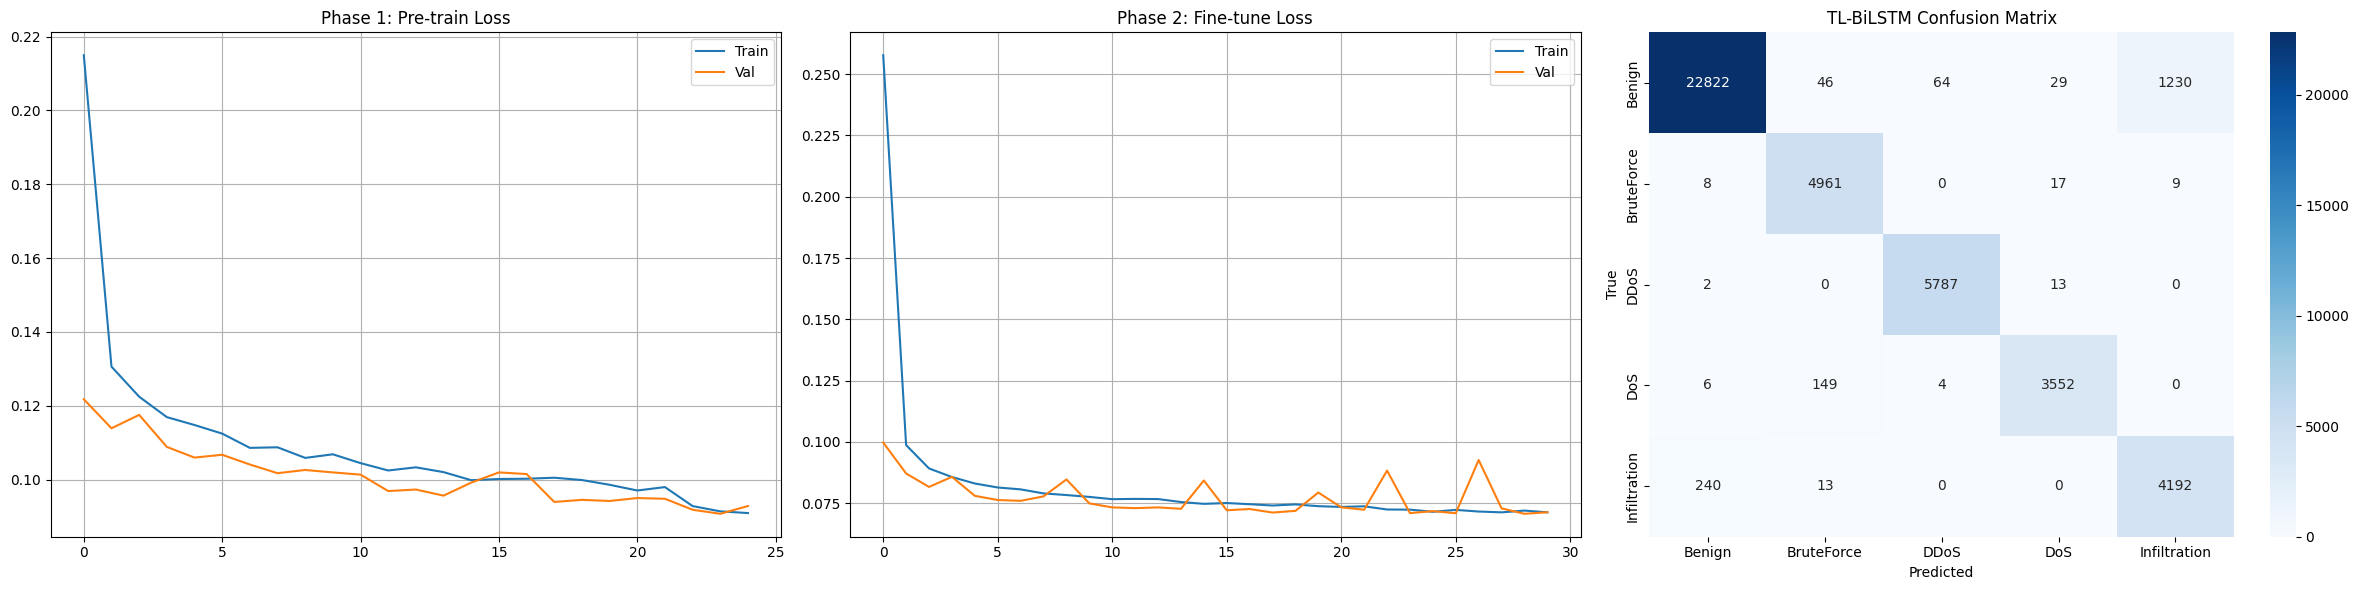

Results saved.


In [9]:
# Load best model
model.load_state_dict(torch.load('../Project/Model/Model_2017/tl_bilstm_best.pth', weights_only=True))
model.eval()

uq_test_loader = create_dataloaders(uq_test, uq_y_test, 'uq', BATCH_SIZE, shuffle=False)
cic_test_loader = create_dataloaders(cic_test, cic_y_test, 'cic', BATCH_SIZE, shuffle=False)

all_preds, all_labels = [], []
with torch.no_grad():
    for loader, dtype in [(uq_test_loader, 'uq'), (cic_test_loader, 'cic')]:
        for x, y, _ in loader:
            x = x.to(DEVICE)
            logits = model(x, dtype)
            preds = logits.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

print("=== TL-BiLSTM Test Results ===\n")
print(classification_report(all_labels, all_preds, target_names=UNIFIED_CLASSES, digits=4))

# Confusion Matrix & Training curves
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

axes[0].plot(pretrain_history['train_loss'], label='Train')
axes[0].plot(pretrain_history['val_loss'], label='Val')
axes[0].set_title('Phase 1: Pre-train Loss')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(finetune_history['train_loss'], label='Train')
axes[1].plot(finetune_history['val_loss'], label='Val')
axes[1].set_title('Phase 2: Fine-tune Loss')
axes[1].legend(); axes[1].grid(True)

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=UNIFIED_CLASSES, yticklabels=UNIFIED_CLASSES, ax=axes[2])
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('True')
axes[2].set_title('TL-BiLSTM Confusion Matrix')

plt.tight_layout()
plt.savefig('../Project/Model/Model_2017/tl_bilstm_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Results saved.")
